In [19]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_27664\2316476194.py:122: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  plt.tight_layout()
e:\ProgramFiles\Anaconda3\envs\LEEDL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


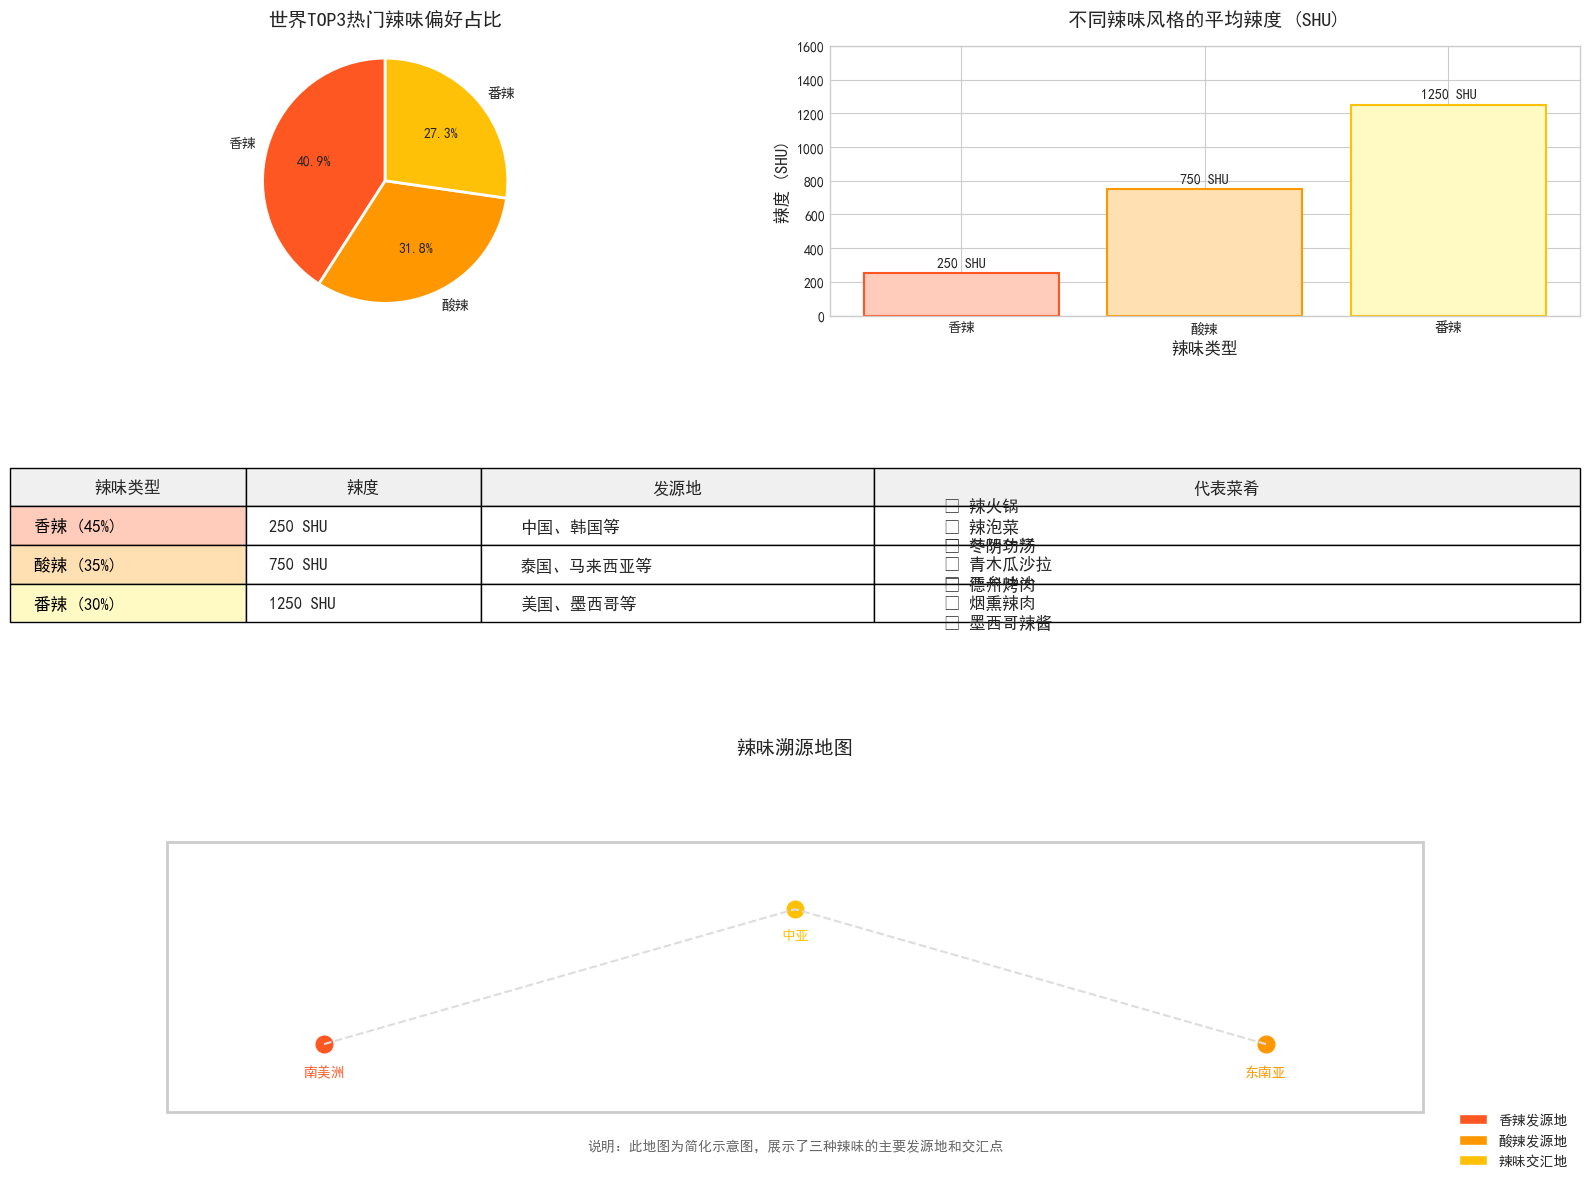

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 数据
spicy_types = ["香辣", "酸辣", "番辣"]
preference_percentages = [45, 35, 30]
scoville_units = [250, 750, 1250]  # 辣度中间值
origins = ["中国、韩国等", "泰国、马来西亚等", "美国、墨西哥等"]
representative_dishes = [
    ["辣火锅", "辣泡菜", "辣炒年糕"],
    ["冬阴功汤", "青木瓜沙拉", "亚参叻沙"],
    ["德州烤肉", "烟熏辣肉", "墨西哥辣酱"]
]

# 颜色定义
colors = ['#FF5722', '#FF9800', '#FFC107']
light_colors = ['#FFCCBC', '#FFE0B2', '#FFF9C4']

# 创建画布
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.5])

# 1. 偏好占比饼图
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(preference_percentages, labels=spicy_types, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'edgecolor': 'w', 'linewidth': 2})
ax1.set_title('世界TOP3热门辣味偏好占比', fontsize=14, pad=15)
ax1.axis('equal')  # 保证饼图是圆的

# 2. 辣度对比条形图
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(spicy_types, scoville_units, color=light_colors, edgecolor=colors, linewidth=1.5)
ax2.set_title('不同辣味风格的平均辣度 (SHU)', fontsize=14, pad=15)
ax2.set_xlabel('辣味类型', fontsize=12)
ax2.set_ylabel('辣度 (SHU)', fontsize=12)
ax2.set_ylim(0, 1600)

# 为每个条形添加数值标签
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{height} SHU', ha='center', va='bottom', fontweight='bold')

# 3. 辣味类型信息表格
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')

# 表格数据
table_data = []
for i, (spicy_type, percentage, scoville, origin, dishes) in enumerate(zip(
    spicy_types, preference_percentages, scoville_units, origins, representative_dishes
)):
    table_data.append([
        f'{spicy_type} ({percentage}%)', 
        f'{scoville} SHU', 
        origin,
        '\n'.join([f'• {dish}' for dish in dishes])
    ])

# 创建表格
table = ax3.table(
    cellText=table_data,
    colLabels=['辣味类型', '辣度', '发源地', '代表菜肴'],
    loc='center',
    cellLoc='left',
    colWidths=[0.15, 0.15, 0.25, 0.45]
)

# 设置表格样式
table.set_fontsize(12)
table.scale(1, 2)  # 调整表格大小

for i in range(len(spicy_types)):
    table[(i+1, 0)].set_facecolor(light_colors[i])
    table[(i+1, 0)].set_text_props(weight='bold', color='black')

for j in range(4):
    table[(0, j)].set_facecolor('#f0f0f0')
    table[(0, j)].set_text_props(weight='bold')

# 4. 辣味溯源地图（简化版）
ax4 = fig.add_subplot(gs[2, :])
ax4.set_title('辣味溯源地图', fontsize=14, pad=15)
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 6)
ax4.axis('off')

# 绘制简化的世界地图轮廓
world_map = plt.Rectangle((1, 1), 8, 4, fill=False, edgecolor='#CCCCCC', linewidth=2)
ax4.add_patch(world_map)

# 绘制辣味发源地和交汇点
origin_points = [
    (2, 2, "南美洲", colors[0]),  # 香辣发源地
    (8, 2, "东南亚", colors[1]),  # 酸辣发源地
    (5, 4, "中亚", colors[2])     # 辣味交汇地
]

# 添加发源地标记
for x, y, name, color in origin_points:
    ax4.plot(x, y, 'o', markersize=12, color=color)
    ax4.text(x, y-0.3, name, ha='center', va='top', fontweight='bold', color=color)

# 添加连接线
ax4.plot([2, 5], [2, 4], '--', color='#DDDDDD')
ax4.plot([8, 5], [2, 4], '--', color='#DDDDDD')

# 添加图例
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='w', label='香辣发源地'),
    Patch(facecolor=colors[1], edgecolor='w', label='酸辣发源地'),
    Patch(facecolor=colors[2], edgecolor='w', label='辣味交汇地')
]
ax4.legend(handles=legend_elements, loc='lower right')

# 添加描述文字
ax4.text(5, 0.5, "说明：此地图为简化示意图，展示了三种辣味的主要发源地和交汇点", 
         ha='center', va='center', fontsize=10, color='#666666')

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# 显示图表
plt.show()

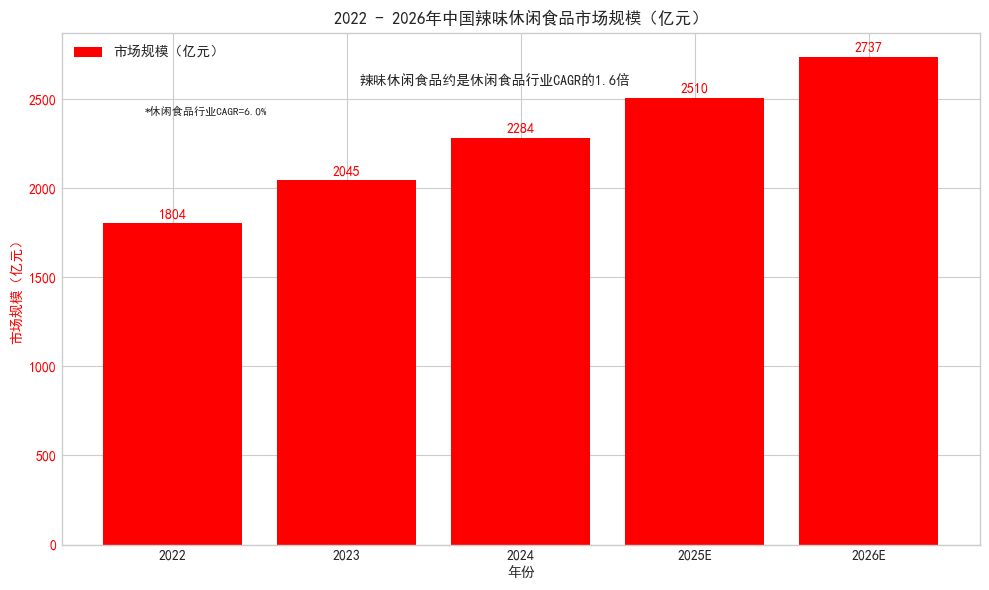

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = np.array([2022, 2023, 2024, 2025, 2026])
# 市场规模数据（亿元），大体模拟原数据趋势
market_size = np.array([1804, 2045, 2284, 2510, 2737])

# 创建图形，设置合理的尺寸
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制柱状图并保存返回的容器对象
bars = ax.bar(years, market_size, color='r', label='市场规模（亿元）')
ax.set_xlabel('年份')
ax.set_ylabel('市场规模（亿元）', color='r')
ax.tick_params(axis='y', labelcolor='r')

# 设置x轴刻度为年份
ax.set_xticks(years)

# 生成带E的年份标签
year_labels = []
for year in years:
    if year in [2025, 2026]:
        year_labels.append(f"{year}E")  # 预测年份添加E
    else:
        year_labels.append(str(year))   # 实际年份保持不变

# 设置带E的年份标签
ax.set_xticklabels(year_labels)

# 在每个条形上方标注数值（不包含E）
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,  # x坐标：条形中心
        height + 15,  # y坐标：条形顶部上方15个单位
        f'{height}',  # 显示数值
        ha='center',  # 水平居中对齐
        va='bottom',  # 垂直底部对齐
        color='r',    # 文字颜色与条形一致
        fontsize=10   # 字体大小
    )

# 添加标题
plt.title('2022 - 2026年中国辣味休闲食品市场规模（亿元）')

# 使用 fig.text() 方法添加注释
fig.text(0.5, 0.85, '辣味休闲食品约是休闲食品行业CAGR的1.6倍',
         ha='center', fontsize=10)

fig.text(0.15, 0.80, '*休闲食品行业CAGR=6.0%', fontsize=8)

# 添加图例
ax.legend(loc='upper left')

# 调整布局
plt.tight_layout()
# 显示图表
plt.show()

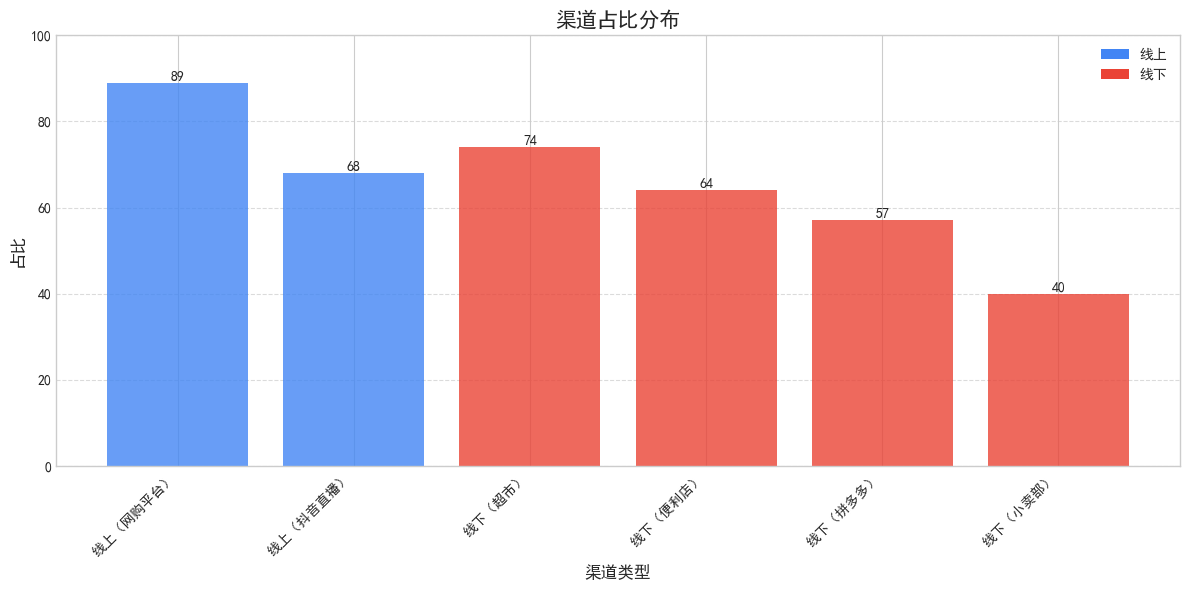

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# 构建数据
data = {
    '渠道': ['线上（网购平台）', '线上（抖音直播）', '线下（超市）', '线下（便利店）', '线下（拼多多）', '线下（小卖部）'],
    '占比': [89, 68, 74, 64, 57, 40]
}
df = pd.DataFrame(data)

# 创建画布
plt.figure(figsize=(12, 6))

# 绘制条形图，区分线上(蓝色)和线下(红色)
colors = ['#4285F4', '#4285F4', '#EA4335', '#EA4335', '#EA4335', '#EA4335']
bars = plt.bar(df['渠道'], df['占比'], color=colors, alpha=0.8)

# 添加数据标签（显示百分比符号）
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom', fontsize=10)

# 设置标题和标签
plt.title('渠道占比分布', fontsize=15)
plt.xlabel('渠道类型', fontsize=12)
plt.ylabel('占比', fontsize=12)

# 设置y轴范围
plt.ylim(0, 100)

# 旋转x轴标签以便更好显示
plt.xticks(rotation=45, ha='right')

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4285F4', label='线上'),
                   Patch(facecolor='#EA4335', label='线下')]
plt.legend(handles=legend_elements, loc='upper right')

# 优化布局
plt.tight_layout()

# 显示图形
plt.show()

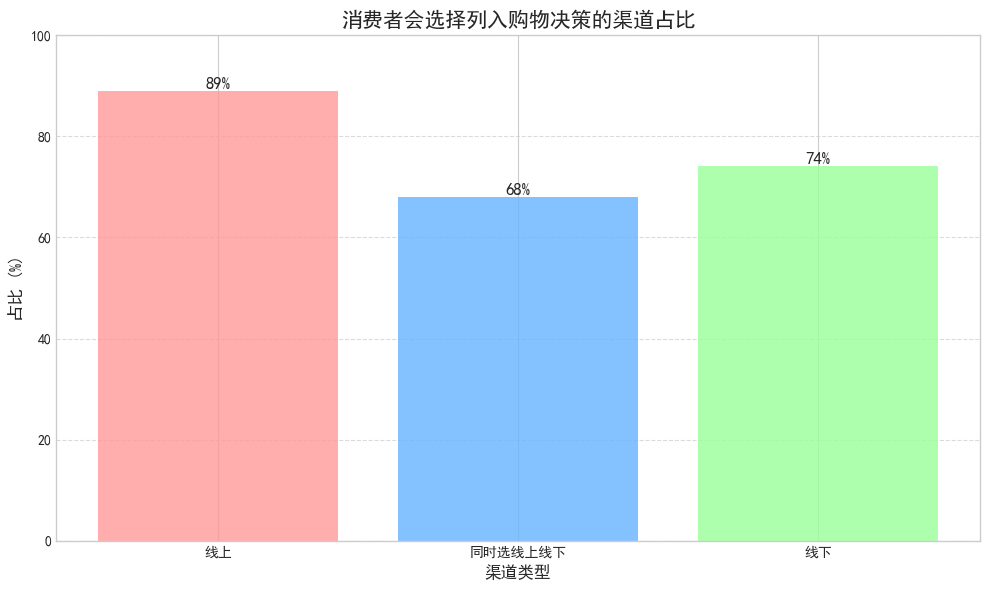

In [25]:
import matplotlib.pyplot as plt

# 数据
channels = ['线上', '同时选线上线下', '线下']
percentages = [89, 68, 74]

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制条形图
bars = plt.bar(channels, percentages, color=['#ff9999', '#66b3ff', '#99ff99'], alpha=0.8)

# 添加数据标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}%',
             ha='center', va='bottom', fontsize=12)

# 设置标题和标签
plt.title('消费者会选择列入购物决策的渠道占比', fontsize=15)
plt.xlabel('渠道类型', fontsize=12)
plt.ylabel('占比 (%)', fontsize=12)

# 设置y轴范围
plt.ylim(0, 100)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 优化布局
plt.tight_layout()

# 显示图形
plt.show()